In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import math
import imageio
import io
from pathlib import Path
from PIL import Image
from brainrender import Scene #3D canvas from brainrender
from brainrender.actors import Points #lets us place dots in 3D space; use for neurons
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache
%matplotlib inline

In [2]:
import os
os.makedirs("C:/Users/grace/brain_data", exist_ok=True)
cache = EcephysProjectCache.from_warehouse(manifest="C:/Users/grace/brain_data/manifest.json")
#connects code to Allen's public online data warehouse instead of downloading all the session data


In [3]:
sessions = cache.get_session_table()
session_id = sessions.index[0] 
#possibly look at specific sessions in future, 
#ones with better data we can take a look at and compare
session = cache.get_session_data(session_id)

units = session.units
spike_times = session.spike_times  
#each key is a specific unit/neuron number and values
# are array of timestamps every time neuron fired a spike during session
print("Session loaded successfully")
print("All regions present:", units['ecephys_structure_acronym'].unique())
print("Unit counts per region:")
print(units['ecephys_structure_acronym'].value_counts())

c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.1.3 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.2.2 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.1.3 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\grace\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\hdmf\spec\namespace.py:535: UserWarning:

Session loaded successfully
All regions present: ['APN' 'DG' 'CA1' 'VISam' 'grey' 'VISpm' 'PO' 'LP' 'PoT' 'VISp' 'LGd'
 'CA3' 'VISl' 'VISrl']
Unit counts per region:
CA1      145
LP       139
grey     117
LGd       82
PO        76
VISrl     76
VISp      60
VISpm     50
VISl      42
VISam     30
APN       26
DG        26
CA3       14
PoT        1
Name: ecephys_structure_acronym, dtype: int64


In [4]:
print(f"Number of probes: {len(session.probes)}")
print("\nProbe info:")
print(session.probes)

# Just show region mapping without the probe ID column
print("\nRegions and unit counts:")
print(units['ecephys_structure_acronym'].value_counts())

Number of probes: 6

Probe info:
          description                 location  sampling_rate  \
id                                                              
810755797      probeA  See electrode locations   29999.954846   
810755799      probeB  See electrode locations   29999.906318   
810755801      probeC  See electrode locations   29999.985470   
810755803      probeD  See electrode locations   29999.908100   
810755805      probeE  See electrode locations   29999.985679   
810755807      probeF  See electrode locations   30000.028033   

           lfp_sampling_rate  has_lfp_data  
id                                          
810755797        1249.998119          True  
810755799        1249.996097          True  
810755801        1249.999395          True  
810755803        1249.996171          True  
810755805        1249.999403          True  
810755807        1250.001168          True  

Regions and unit counts:
CA1      145
LP       139
grey     117
LGd       82
PO      

In [5]:
all_spike_times = np.concatenate(list(session.spike_times.values()))
t_start = all_spike_times.min()
t_end = all_spike_times.max()
print(f"Session runs from {t_start: .1f}s to {t_end:.1f}s")

Session runs from  11.9s to 9640.7s


In [6]:
#each session may use anywhere between 4-6 probes
#see which regions actually present in each session
present_regions = list(units['ecephys_structure_acronym'].unique())
present_regions = [r for r in present_regions if isinstance(r, str)]

print(f"Found {len(present_regions)} regions: {present_regions}")

# Auto assign a color for each region
cmap = cm.get_cmap('tab10', len(present_regions))
REGION_COLORS_MPL = {
    region: cmap(i)[:3] for i, region in enumerate(present_regions)
}

# BrainRender needs RGB 0-255 integers
REGION_COLORS_BR = {
    region: [int(c * 255) for c in color]
    for region, color in REGION_COLORS_MPL.items()
}

print("\nRegion colors assigned:")
for region, color in REGION_COLORS_MPL.items():
    print(f"  {region}: {color}")

Found 14 regions: ['APN', 'DG', 'CA1', 'VISam', 'grey', 'VISpm', 'PO', 'LP', 'PoT', 'VISp', 'LGd', 'CA3', 'VISl', 'VISrl']

Region colors assigned:
  APN: (0.12156862745098039, 0.4666666666666667, 0.7058823529411765)
  DG: (0.12156862745098039, 0.4666666666666667, 0.7058823529411765)
  CA1: (1.0, 0.4980392156862745, 0.054901960784313725)
  VISam: (0.17254901960784313, 0.6274509803921569, 0.17254901960784313)
  grey: (0.8392156862745098, 0.15294117647058825, 0.1568627450980392)
  VISpm: (0.8392156862745098, 0.15294117647058825, 0.1568627450980392)
  PO: (0.5803921568627451, 0.403921568627451, 0.7411764705882353)
  LP: (0.5490196078431373, 0.33725490196078434, 0.29411764705882354)
  PoT: (0.8901960784313725, 0.4666666666666667, 0.7607843137254902)
  VISp: (0.8901960784313725, 0.4666666666666667, 0.7607843137254902)
  LGd: (0.4980392156862745, 0.4980392156862745, 0.4980392156862745)
  CA3: (0.7372549019607844, 0.7411764705882353, 0.13333333333333333)
  VISl: (0.09019607843137255, 0.745098

C:\Users\grace\AppData\Local\Temp\ipykernel_23688\472272555.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(present_regions))


In [7]:
def compute_firing_rates(spike_times, t_start, t_end, bin_size=1.0):
    bins = np.arange(t_start, t_end, bin_size)
    rates = {}
    for uid, spikes in spike_times.items():
        counts, _ = np.histogram(spikes, bins=bins) #counting how many spikes fall into each 1 sec bin
        rates[uid] = counts / bin_size #converting spike count into firing rate in spikes per sec(Hz)
    return rates, bins

all_rates, bins = compute_firing_rates(session.spike_times, t_start, t_end, bin_size=1.0)
print(f"Computed firing rates across {len(bins)-1} timesteps")

Computed firing rates across 9628 timesteps


In [8]:
#Normalizing rates by creating another reusable function, scales neuron's firing rates between 0 and 1
def normalize_rates(rates_over_time):
    normalized = {}
    for uid, r in rates_over_time.items():
        rng = r.max() - r.min()
        normalized[uid] = (r - r.min()) / (rng + 1e-9) #add 1e-9 to prevent error by dividing by 0 if a neuron doesn't fire
    return normalized
#now can map firing rates with brightness during video
# with 0 completely dark and 1 fully bright
normalized = normalize_rates(all_rates)
print("Normalization complete")

Normalization complete


In [9]:
print("available column:", units.columns.tolist())
units_with_coords = units.dropna(subset=[
    'anterior_posterior_ccf_coordinate',
    'dorsal_ventral_ccf_coordinate',
    'left_right_ccf_coordinate'
])
#to drop units without any coordinates
print(f"\nUnits with coordinates: {len(units_with_coords)} of {len(units)} total")
print("\nRegions with coordinates:")
print(units_with_coords['ecephys_structure_acronym'].value_counts())

available column: ['waveform_PT_ratio', 'waveform_amplitude', 'amplitude_cutoff', 'cluster_id', 'cumulative_drift', 'd_prime', 'firing_rate', 'isi_violations', 'isolation_distance', 'L_ratio', 'local_index', 'max_drift', 'nn_hit_rate', 'nn_miss_rate', 'peak_channel_id', 'presence_ratio', 'waveform_recovery_slope', 'waveform_repolarization_slope', 'silhouette_score', 'snr', 'waveform_spread', 'waveform_velocity_above', 'waveform_velocity_below', 'waveform_duration', 'filtering', 'probe_channel_number', 'probe_horizontal_position', 'probe_id', 'probe_vertical_position', 'structure_acronym', 'ecephys_structure_id', 'ecephys_structure_acronym', 'anterior_posterior_ccf_coordinate', 'dorsal_ventral_ccf_coordinate', 'left_right_ccf_coordinate', 'probe_description', 'location', 'probe_sampling_rate', 'probe_lfp_sampling_rate', 'probe_has_lfp_data']

Units with coordinates: 717 of 884 total

Regions with coordinates:
CA1      145
LP       139
LGd       82
PO        76
VISrl     76
VISp      60


In [53]:
def build_brainrender_scene(units_with_coords, t_idx, normalized):
    # Fix: make sure t_idx is a plain integer
    t_idx = int(t_idx)
    
    # Fix: use proper f-string formatting
    scene = Scene(title=f"Neural activity t={t_idx}s")
    
    # Add each brain region mesh as semi transparent
    for region in present_regions:
        try:
            scene.add_brain_region(region, alpha=0.15)
        except Exception as e:
            print(f"Could not add region {region}: {e}")
    
    # Add neuron dots for each region
    for region in present_regions:
        region_units = units_with_coords[
            units_with_coords['ecephys_structure_acronym'] == region
        ]
        
        if len(region_units) == 0:
            continue
        
        coords = np.column_stack([
            region_units['anterior_posterior_ccf_coordinate'],
            region_units['dorsal_ventral_ccf_coordinate'],
            region_units['left_right_ccf_coordinate']
        ])
        
        base_color = REGION_COLORS_BR[region]
        colors = []
        for uid in region_units.index:
            rate_array = normalized.get(uid, np.zeros(len(bins)-1))
            # Make sure t_idx is within bounds
            t_idx_safe = min(t_idx, len(rate_array) - 1)
            brightness = float(rate_array[t_idx_safe])
            # Boost contrast significantly so differences are visible
            brightness = float(np.clip(brightness ** 0.3, 0.1, 1.0))
            scaled = [int(c * brightness) for c in base_color]
            colors.append(scaled)
        
        points = Points(
            coords,
            name=region,
            colors=colors,
            radius=50  # increased from 30 so dots are more visible
        )
        scene.add(points)
    
    return scene
        

In [54]:
scene = build_brainrender_scene(units_with_coords, t_idx=0, normalized=normalized)
scene.render()

In [55]:
import vedo
import shutil

vedo.settings.default_backend = "offscreen"

frames_dir = Path("C:/Users/grace/brain_data/brainrender_frames")

if frames_dir.exists():
    shutil.rmtree(frames_dir)
frames_dir.mkdir(parents=True, exist_ok=True)

# Start 15 seconds before peak activity
t_start_frame = peak_t - 15
t_start_frame = max(0, t_start_frame)
n_frames = 30

print(f"Rendering {n_frames} frames starting from t={t_start_frame} (peak at t={peak_t})")

for i, t in enumerate(range(t_start_frame, t_start_frame + n_frames)):
    scene = build_brainrender_scene(units_with_coords, t_idx=t, normalized=normalized)
    
    frame_path = str(frames_dir / f"frame_{i:04d}.png")
    
    scene.render(interactive=False)
    scene.plotter.show(interactive=False)
    scene.plotter.screenshot(frame_path, scale=1)
    scene.close()
    
    if i % 5 == 0:
        saved_files = list(frames_dir.glob("*.png"))
        print(f"Rendered frame {i} of {n_frames} — {len(saved_files)} files saved")

print(f"\nDone! Total frames saved: {len(list(frames_dir.glob('*.png')))}")

Rendering 30 frames starting from t=2004 (peak at t=2019)
Rendered frame 0 of 30 — 1 files saved
Rendered frame 5 of 30 — 6 files saved
Rendered frame 10 of 30 — 11 files saved
Rendered frame 15 of 30 — 16 files saved
Rendered frame 20 of 30 — 21 files saved
Rendered frame 25 of 30 — 26 files saved

Done! Total frames saved: 30


In [56]:
output_video = "C:/Users/grace/brain_data/brainrender_activity.mp4"
writer = imageio.get_writer(output_video, fps=1)

frame_files = sorted(frames_dir.glob("frame_*.png"))
print(f"Found {len(frame_files)} frames to assemble")

for frame_path in frame_files:
    frame = np.array(Image.open(frame_path))
    writer.append_data(frame)

writer.close()
print(f"Video saved to {output_video}")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1508, 984) to (1520, 992) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Found 30 frames to assemble
Video saved to C:/Users/grace/brain_data/brainrender_activity.mp4


In [57]:
from IPython.display import Video
Video(output_video, embed=True)

<IPython.core.display.Video object>

In [45]:
# Find the most active time period
import numpy as np

# Stack all normalized rates into a matrix (n_units x n_timesteps)
all_units = list(normalized.keys())
rate_matrix = np.array([normalized[uid] for uid in all_units])

# Compute mean activity across all neurons at each timestep
mean_activity = rate_matrix.mean(axis=0)

# Find the timestep with highest average activity
peak_t = np.argmax(mean_activity)
print(f"Peak activity at timestep: {peak_t}")
print(f"That corresponds to: {peak_t:.0f} seconds into the session")

# Show activity levels across time in chunks
chunk_size = 500
for i in range(0, min(5000, len(mean_activity)), chunk_size):
    chunk_mean = mean_activity[i:i+chunk_size].mean()
    print(f"t={i}-{i+chunk_size}s mean activity: {chunk_mean:.4f}")

Peak activity at timestep: 2019
That corresponds to: 2019 seconds into the session
t=0-500s mean activity: 0.1208
t=500-1000s mean activity: 0.1402
t=1000-1500s mean activity: 0.1360
t=1500-2000s mean activity: 0.1455
t=2000-2500s mean activity: 0.1737
t=2500-3000s mean activity: 0.1724
t=3000-3500s mean activity: 0.1594
t=3500-4000s mean activity: 0.1451
t=4000-4500s mean activity: 0.1688
t=4500-5000s mean activity: 0.1579


Frame 0 (t_start):


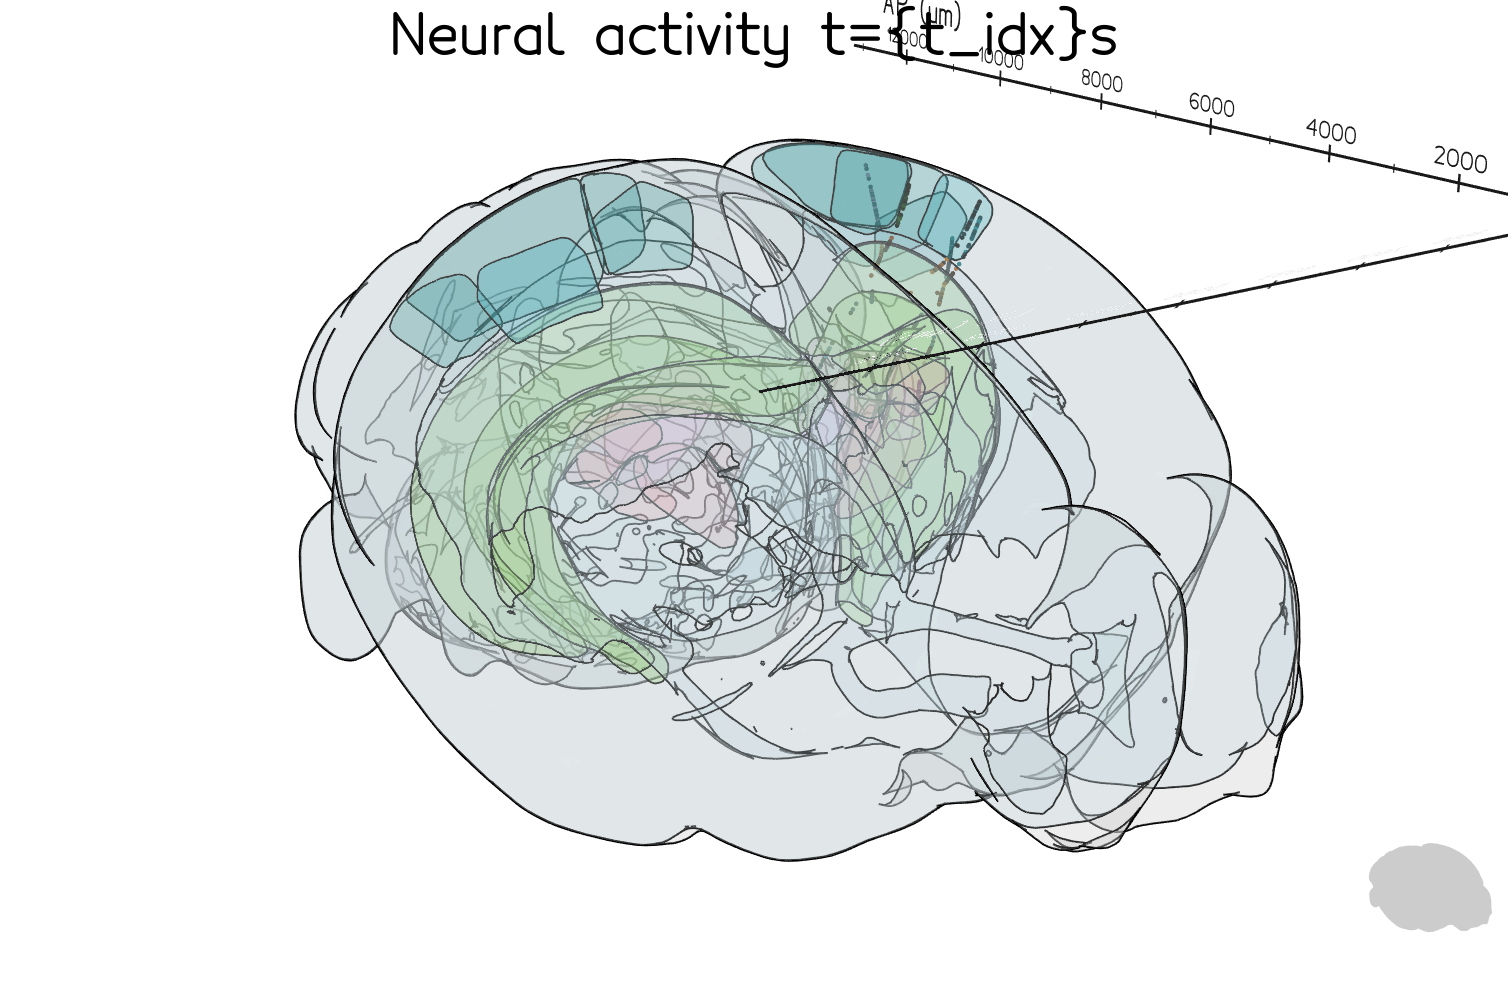

Frame 29 (t_start+29):


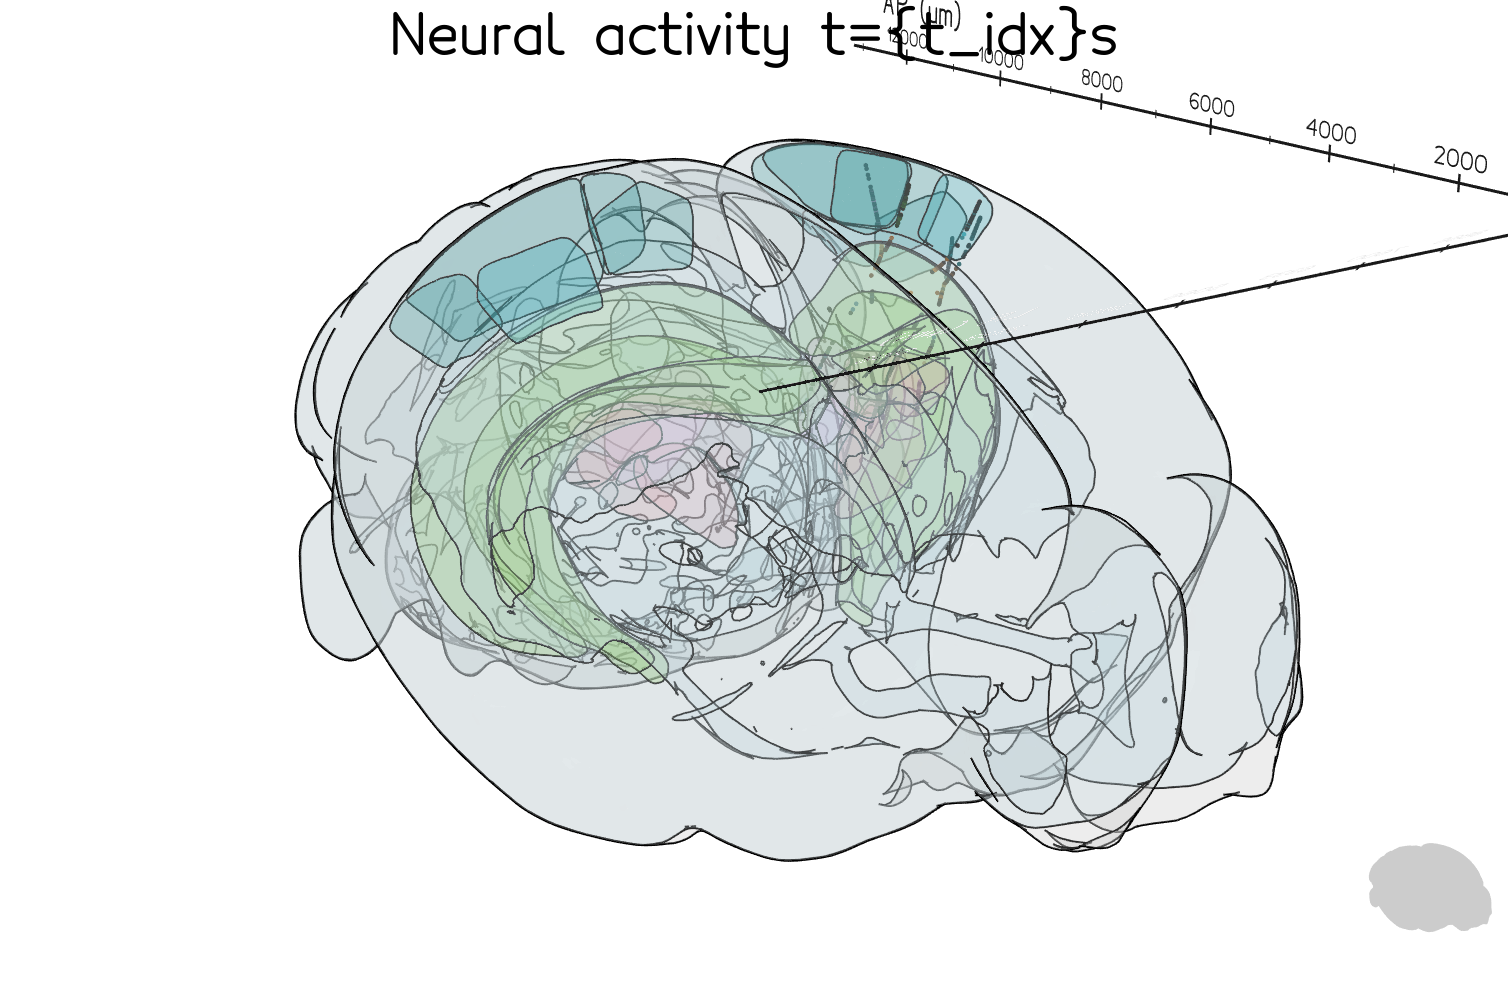

In [52]:
from IPython.display import Image as IPImage
import ipywidgets as widgets

# Display frame 0 and frame 29 side by side to see if anything changed
frame0 = str(frames_dir / "frame_0000.png")
frame29 = str(frames_dir / "frame_0029.png")

print("Frame 0 (t_start):")
display(IPImage(frame0, width=400))

print(f"Frame 29 (t_start+29):")
display(IPImage(frame29, width=400))